In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp
import joblib
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Load original training data as "baseline"
df_baseline = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_baseline['TotalCharges'] = pd.to_numeric(df_baseline['TotalCharges'], errors='coerce')
df_baseline = df_baseline.dropna(subset=['TotalCharges'])

# Load model
pipeline = joblib.load('../models/phase4_logistic_regression.pkl')

print(f"Baseline data: {df_baseline.shape}")

Baseline data: (7032, 21)


In [7]:
# Simulate a drifted dataset (in production, this would be new incoming data)
df_new = df_baseline.copy()

# Simulate drift: new customers have shorter tenure, higher monthly charges
np.random.seed(42)
df_new['tenure'] = np.clip(df_new['tenure'] * np.random.uniform(0.5, 0.9, size=len(df_new)), 1, 72).astype(int)
df_new['MonthlyCharges'] = df_new['MonthlyCharges'] * np.random.uniform(1.1, 1.4, size=len(df_new))

# More month-to-month contracts
contract_noise = np.random.random(size=len(df_new))
df_new.loc[contract_noise < 0.15, 'Contract'] = 'Month-to-month'

print("Simulated drift applied")
print(f"New avg tenure: {df_new['tenure'].mean():.1f} (baseline: {df_baseline['tenure'].mean():.1f})")
print(f"New avg monthly: ${df_new['MonthlyCharges'].mean():.2f} (baseline: ${df_baseline['MonthlyCharges'].mean():.2f})")

Simulated drift applied
New avg tenure: 22.2 (baseline: 32.4)
New avg monthly: $80.94 (baseline: $64.80)


       feature  ks_statistic       p_value  drift_detected
        tenure      0.228385 4.029223e-161            True
MonthlyCharges      0.254835 6.087165e-201            True
  TotalCharges      0.000000  1.000000e+00           False


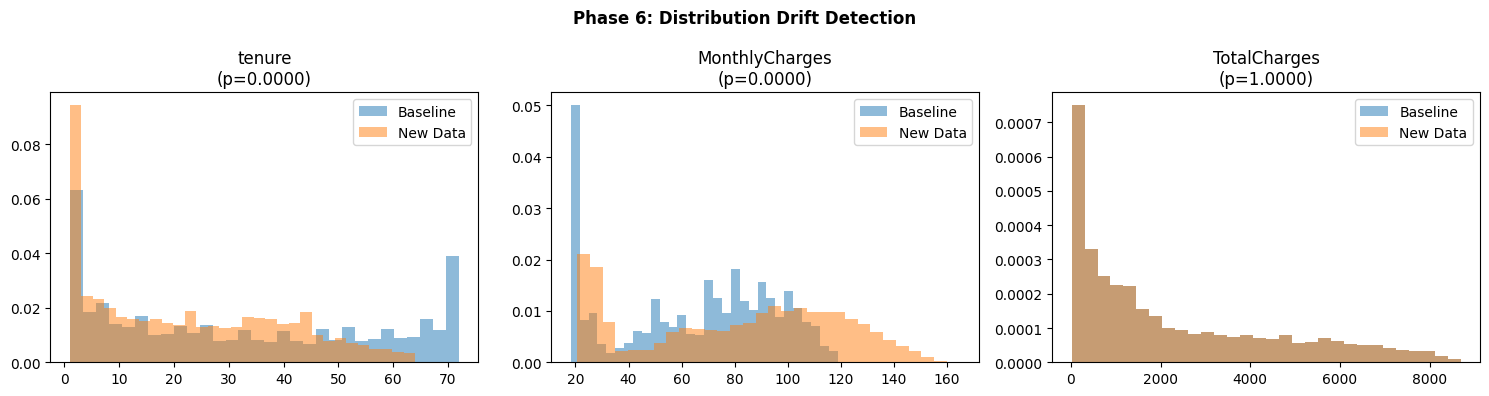

In [8]:
from scipy.stats import ks_2samp

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

drift_results = []
for col in numeric_cols:
    stat, pvalue = ks_2samp(df_baseline[col], df_new[col])
    drift_results.append({
        'feature': col,
        'ks_statistic': stat,
        'p_value': pvalue,
        'drift_detected': pvalue < 0.05
    })

drift_df = pd.DataFrame(drift_results)
print(drift_df.to_string(index=False))

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    axes[i].hist(df_baseline[col], bins=30, alpha=0.5, label='Baseline', density=True)
    axes[i].hist(df_new[col], bins=30, alpha=0.5, label='New Data', density=True)
    axes[i].set_title(f'{col}\n(p={drift_df[drift_df["feature"]==col]["p_value"].values[0]:.4f})')
    axes[i].legend()
plt.suptitle('Phase 6: Distribution Drift Detection', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/phase6_drift_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_11062/3365596926.py:17: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11062/3365596926.py:18: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig('../reports/figures/phase6_prediction_drift.png', dpi=150, bbox_inches='tight')
/home/codespace/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


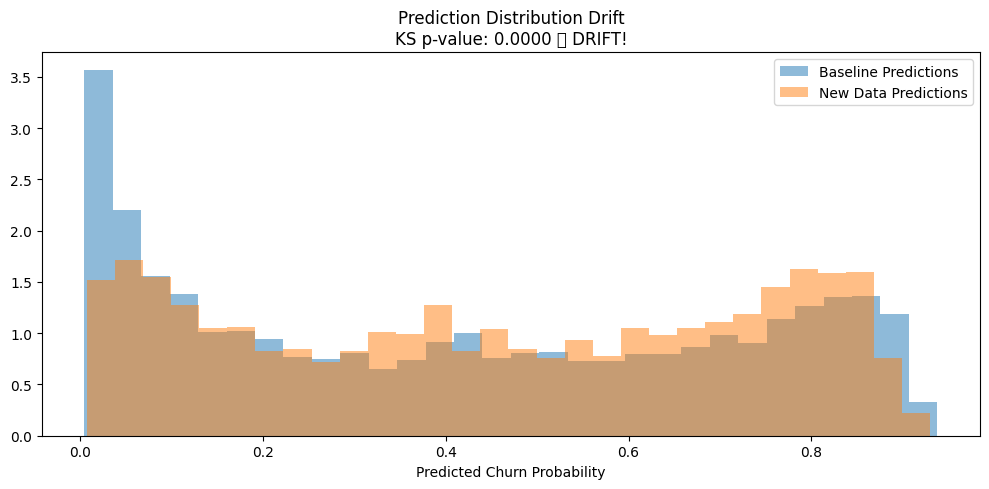

Mean prediction (baseline): 0.415
Mean prediction (new):      0.458


In [9]:
# Score both datasets
X_baseline = df_baseline.drop(['customerID', 'Churn'], axis=1, errors='ignore')
X_new = df_new.drop(['customerID', 'Churn'], axis=1, errors='ignore')

proba_baseline = pipeline.predict_proba(X_baseline)[:, 1]
proba_new = pipeline.predict_proba(X_new)[:, 1]

# Compare prediction distributions
stat, pvalue = ks_2samp(proba_baseline, proba_new)

plt.figure(figsize=(10, 5))
plt.hist(proba_baseline, bins=30, alpha=0.5, label='Baseline Predictions', density=True)
plt.hist(proba_new, bins=30, alpha=0.5, label='New Data Predictions', density=True)
plt.title(f'Prediction Distribution Drift\nKS p-value: {pvalue:.4f} {"🚨 DRIFT!" if pvalue < 0.05 else "✅ Stable"}')
plt.xlabel('Predicted Churn Probability')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/phase6_prediction_drift.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean prediction (baseline): {proba_baseline.mean():.3f}")
print(f"Mean prediction (new):      {proba_new.mean():.3f}")

In [10]:
# Compare coefficient rankings between baseline and new data
# (In practice, you'd retrain and compare)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Quick retrain on "new" data to see if coefficients shifted
y_new = df_new['Churn'].map({'No': 0, 'Yes': 1})
X_new_train = df_new.drop(['customerID', 'Churn'], axis=1, errors='ignore')

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_features = [c for c in X_new_train.columns if c not in numeric_features]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

new_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

new_pipeline.fit(X_new_train, y_new)

# Compare top features
old_coef = pd.Series(pipeline.named_steps['classifier'].coef_[0])
new_coef = pd.Series(new_pipeline.named_steps['classifier'].coef_[0])

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

comparison = pd.DataFrame({
    'feature': feature_names,
    'baseline_coef': old_coef.values,
    'new_coef': new_coef.values,
    'shift': np.abs(old_coef.values - new_coef.values)
}).sort_values('shift', ascending=False)

print("Top coefficient shifts (concept drift indicators):")
print(comparison.head(10).to_string(index=False))

Top coefficient shifts (concept drift indicators):
                              feature  baseline_coef  new_coef    shift
                       MonthlyCharges      -0.476384  0.063614 0.539998
                         TotalCharges       0.610057  0.167170 0.442887
          InternetService_Fiber optic       1.125391  0.816315 0.309077
                               tenure      -1.258362 -0.964351 0.294010
       MultipleLines_No phone service      -0.072970  0.141692 0.214662
                    Contract_Two year      -1.445120 -1.237332 0.207788
                 DeviceProtection_Yes       0.069509 -0.095298 0.164807
PaymentMethod_Credit card (automatic)       0.079969 -0.084804 0.164772
                      StreamingTV_Yes       0.382479  0.220735 0.161744
                    Contract_One year      -0.785572 -0.632808 0.152763


In [11]:
# Define retraining trigger
RETRAIN_THRESHOLD = 0.05  # KS p-value

drift_detected = pvalue < RETRAIN_THRESHOLD

print("=" * 50)
print("MONITORING REPORT")
print("=" * 50)
print(f"Data drift detected:     {drift_df['drift_detected'].any()}")
print(f"Prediction drift:        {drift_detected} (p={pvalue:.4f})")
print(f"Coefficient shift:       {comparison['shift'].max():.3f} (max)")

if drift_detected:
    print("\n🚨 TRIGGER: Retraining recommended!")
    print("Action: Collect new labels, retrain model, A/B test deployment")
else:
    print("\n✅ Model stable. Continue monitoring.")

MONITORING REPORT
Data drift detected:     True
Prediction drift:        True (p=0.0000)
Coefficient shift:       0.540 (max)

🚨 TRIGGER: Retraining recommended!
Action: Collect new labels, retrain model, A/B test deployment
